#  Claim Severity Modeling using XGBoost

## Business Context

The previous notebook developed two classical actuarial severity models:

- Gamma Generalized Linear Model (GLM)
- Tweedie Generalized Linear Model (GLM)

While these models are transparent and widely accepted in insurance pricing, they rely on predefined functional relationships between predictor variables and claim severity.

Modern machine learning algorithms such as **Extreme Gradient Boosting (XGBoost)** can automatically learn complex nonlinear relationships and interactions between policyholder characteristics without requiring explicit model specification.

The objective of this notebook is to develop an XGBoost severity model and evaluate whether it provides improved predictive performance over the classical GLM benchmarks.

---

## Objectives

By the end of this notebook we will:

- Develop an XGBoost regression model for claim severity.
- Evaluate predictive performance using RMSE, MAE, and Gamma Deviance.
- Interpret feature importance.
- Compare XGBoost against Gamma and Tweedie GLMs.
- Select the best-performing severity model for the Pure Premium framework.

# 1. Import Required Libraries

This notebook combines statistical computing, machine learning, and visualization libraries.

The imported packages support:

- Data manipulation
- Feature preprocessing
- Gradient boosting
- Model evaluation
- Visualization

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_gamma_deviance
)

from xgboost import XGBRegressor

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)

# 2. Load Severity Dataset

The severity modeling dataset prepared during Day 6 is loaded for machine learning model development.

The dataset contains:

- Policy characteristics
- Driver characteristics
- Vehicle characteristics
- Geographic variables
- Claim severity

The response variable remains the average claim cost per reported claim.

In [9]:
import pandas as pd
import numpy as np

# Load frequency (policy) dataset
policy_df = pd.read_csv(r"D:\Insurance_Pricing_Project\Data\freMTPL2freq.csv")

# Load severity (claims) dataset
claim_df = pd.read_csv(r"D:\Insurance_Pricing_Project\Data\freMTPL2sev.csv")

# 3. Validate Dataset

Before training the machine learning model, we verify the structure of the dataset.

The following checks are performed:

- Dataset dimensions
- Missing values
- Data types
- Summary statistics

These checks ensure the data is suitable for supervised learning.

In [5]:
print("Dataset Shape:", severity_df.shape)

severity_df.info()

severity_df.describe()

Dataset Shape: (26639, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26639 entries, 0 to 26638
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   IDpol        26639 non-null  int64  
 1   ClaimAmount  26639 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 416.4 KB


,IDpol,ClaimAmount
count,2.663900e+04,2.663900e+04
mean,2.279864e+06,2.278536e+03
std,1.577202e+06,2.929748e+04
min,1.390000e+02,1.000000e+00
25%,1.087642e+06,6.868100e+02
50%,2.137413e+06,1.172000e+03
75%,3.180162e+06,1.228080e+03
max,6.113971e+06,4.075401e+06


In [11]:
claim_summary = (
    claim_df
    .groupby("IDpol")
    .agg(
        TotalClaimAmount=("ClaimAmount", "sum"),
        NumberOfClaims=("ClaimAmount", "count")
    )
    .reset_index()
)

In [12]:
severity_df = policy_df.merge(
    claim_summary,
    on="IDpol",
    how="inner"
)

In [13]:
severity_df["Severity"] = (
    severity_df["TotalClaimAmount"] /
    severity_df["NumberOfClaims"]
)

In [14]:
severity_df.columns

Index(['IDpol', 'ClaimNb', 'Exposure', 'Area', 'VehPower', 'VehAge', 'DrivAge',
       'BonusMalus', 'VehBrand', 'VehGas', 'Density', 'Region',
       'TotalClaimAmount', 'NumberOfClaims', 'Severity'],
      dtype='object')

# 4. Define Feature Matrix and Target Variable

Before model training, the predictor variables (features) and response variable (target) must be defined.

## Target Variable

The response variable is **Severity**, representing the average claim cost for policies with at least one reported claim.

\[
Severity = \frac{\text{Total Claim Amount}}{\text{Number of Claims}}
\]

## Feature Selection

The following variables are excluded from model training:

- **IDpol**: Unique policy identifier with no predictive value.
- **TotalClaimAmount**: Directly used to construct the target variable.
- **NumberOfClaims**: Used to compute severity and would introduce target leakage.

Removing these variables ensures that the model learns relationships from genuine risk characteristics available at pricing time.

In [15]:
target = "Severity"

drop_columns = [
    "IDpol",
    "TotalClaimAmount",
    "NumberOfClaims"
]

X = severity_df.drop(columns=drop_columns + [target])

y = severity_df[target]

print(f"Feature Matrix Shape : {X.shape}")
print(f"Target Vector Shape  : {y.shape}")

Feature Matrix Shape : (24944, 11)
Target Vector Shape  : (24944,)


# 5. Train-Test Split

The dataset is divided into training and testing subsets.

- **80%** of the data is used for model training.
- **20%** is reserved for evaluating model performance on unseen observations.

A fixed random seed ensures that the results are reproducible.

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(f"Training Samples : {X_train.shape[0]:,}")
print(f"Testing Samples  : {X_test.shape[0]:,}")

Training Samples : 19,955
Testing Samples  : 4,989


# 6. Feature Classification

The dataset contains both numerical and categorical predictors.

To prepare the data for machine learning, the variables are classified into:

- **Numerical Features**
- **Categorical Features**

This enables different preprocessing techniques to be applied to each feature type.

In [17]:
categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['Area', 'VehBrand', 'VehGas', 'Region']

Numerical Features:
['ClaimNb', 'Exposure', 'VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'Density']


# 7. Feature Classification

The dataset contains both numerical and categorical predictors.

To prepare the data for machine learning, the variables are classified into:

- **Numerical Features**
- **Categorical Features**

This enables different preprocessing techniques to be applied to each feature type.

In [18]:
categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['Area', 'VehBrand', 'VehGas', 'Region']

Numerical Features:
['ClaimNb', 'Exposure', 'VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'Density']


# 8. Data Preprocessing Pipeline

Machine learning models require numerical inputs.

A preprocessing pipeline is constructed to automate data transformation:

### Numerical Variables

- Missing values are imputed using the median.

### Categorical Variables

- Missing values are imputed using the most frequent category.
- One-hot encoding converts categorical variables into binary indicator variables.

The pipeline ensures that identical transformations are applied during both training and prediction.

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [20]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    objective="reg:gamma",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    tree_method="hist"
)

# 10. Machine Learning Pipeline

The preprocessing steps and XGBoost model are combined into a single pipeline.

This ensures that:

- Data preprocessing is consistently applied.
- The workflow is reproducible.
- The trained model can be deployed with minimal additional code.

In [21]:
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", xgb_model)
    ]
)

# 11. Train the XGBoost Severity Model

The pipeline is fitted using the training dataset.

During training, XGBoost iteratively minimizes the Gamma loss function by constructing an ensemble of decision trees.

The resulting model estimates expected claim severity based on policyholder, vehicle, and geographic characteristics.

In [23]:
xgb_pipeline.fit(X_train, y_train)

print("XGBoost Severity Model trained successfully.")

XGBoost Severity Model trained successfully.


# 12. Generate Claim Severity Predictions

## Objective

Following model training, the fitted XGBoost model is applied to the independent testing dataset to generate out-of-sample predictions.

These predictions represent the **expected claim severity**, conditional on a claim occurring.

Mathematically, the model estimates:

\[
\hat{S}_i = E(S_i \mid X_i)
\]

where:

- \(S_i\) is the observed claim severity.
- \(X_i\) represents the policyholder, vehicle, and geographic characteristics.
- \(\hat{S}_i\) is the predicted average claim cost.

---

## Why Out-of-Sample Predictions?

Evaluating a model on unseen observations provides a realistic estimate of its ability to generalize beyond the training data.

In insurance pricing, strong out-of-sample performance is critical because pricing models are ultimately deployed to estimate premiums for **future policyholders**, not the historical data used to train the model.

---

## Expected Output

The resulting predictions will be compared against the observed claim severities using multiple statistical performance metrics.

These predictions will also form the severity component of the **Pure Premium Framework** developed in the next stage of the project.

In [24]:
# Generate predictions on the testing dataset

xgb_predictions = xgb_pipeline.predict(X_test)

# Ensure all predictions are strictly positive
xgb_predictions = np.clip(xgb_predictions, 0, None)

print("First 10 Predicted Severities:")
print(xgb_predictions[:10])

First 10 Predicted Severities:
[1995.8427 2193.6272 1291.4049 1123.4445 1860.8809 1074.8646 1742.5382
 2562.726  1754.229  1295.3323]


# 13. Evaluate Predictive Performance

## Objective

Model performance is assessed using three complementary evaluation metrics that are widely adopted in actuarial science and predictive analytics.

A single metric rarely captures every aspect of predictive quality. Therefore, multiple metrics are used to evaluate both numerical accuracy and distributional fit.

---

## Root Mean Squared Error (RMSE)

RMSE measures the square root of the average squared prediction error.

\[
RMSE =
\sqrt{
\frac{1}{n}
\sum_{i=1}^{n}
(y_i-\hat{y}_i)^2
}
\]

Large prediction errors receive greater weight, making RMSE particularly useful for insurance claims where high-severity losses have substantial financial consequences.

Lower RMSE indicates better predictive accuracy.

---

## Mean Absolute Error (MAE)

MAE represents the average absolute difference between observed and predicted claim severity.

\[
MAE=
\frac{1}{n}
\sum
|y_i-\hat{y}_i|
\]

Unlike RMSE, MAE assigns equal weight to all prediction errors and provides an intuitive measure of average pricing accuracy.

---

## Gamma Deviance

Because claim severity is modeled using a Gamma distribution, Gamma Deviance provides a distribution-specific goodness-of-fit measure.

It evaluates how closely the predicted severity distribution aligns with the observed losses.

Lower Gamma Deviance indicates better agreement between predicted and observed claim costs.

---

## Business Interpretation

A severity model with lower RMSE, MAE, and Gamma Deviance is expected to produce more accurate claim cost estimates.

Improved severity estimation directly contributes to more accurate premium calculations, stronger reserve adequacy, and reduced pricing uncertainty.

In [25]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_gamma_deviance
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_predictions
    )
)

xgb_mae = mean_absolute_error(
    y_test,
    xgb_predictions
)

xgb_gamma_deviance = mean_gamma_deviance(
    y_test,
    xgb_predictions
)

xgb_metrics = pd.DataFrame({
    "Metric": [
        "RMSE",
        "MAE",
        "Gamma Deviance"
    ],
    "Value": [
        xgb_rmse,
        xgb_mae,
        xgb_gamma_deviance
    ]
})

xgb_metrics.round(4)

,Metric,Value
0,RMSE,11874.8318
1,MAE,1524.4381
2,Gamma Deviance,1.5505


# 15. Global Feature Importance

## Objective

Unlike linear regression models, XGBoost captures nonlinear relationships through an ensemble of decision trees.

Although individual trees may be difficult to interpret, feature importance provides a global summary of which variables contribute most to predictive performance.

---

## Importance Measures

XGBoost estimates feature importance based on the cumulative contribution of each predictor across all decision trees.

Higher importance values indicate variables that frequently improve prediction accuracy.

---

## Business Value

Understanding the most influential pricing variables provides several benefits:

- Supports actuarial interpretation.
- Validates business assumptions.
- Identifies primary risk drivers.
- Assists pricing governance and regulatory review.

Feature importance also provides an initial explanation before applying SHAP values, which offer observation-level explanations in Day 9.

In [26]:
feature_names = (
    xgb_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importance = (
    xgb_pipeline
    .named_steps["model"]
    .feature_importances_
)

importance_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance
    })
    .sort_values(
        "Importance",
        ascending=False
    )
)

importance_df.head(20)

,Feature,Importance
4,num__DrivAge,0.065101
15,cat__VehBrand_B11,0.057604
1,num__Exposure,0.037078
7,cat__Area_A,0.034096
30,cat__Region_R24,0.031167
26,cat__Region_R11,0.030637
0,num__ClaimNb,0.027411
19,cat__VehBrand_B2,0.027291
46,cat__Region_R93,0.026206
16,cat__VehBrand_B12,0.025064


C:\Users\Umer\AppData\Local\Temp\ipykernel_1032\46516097.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


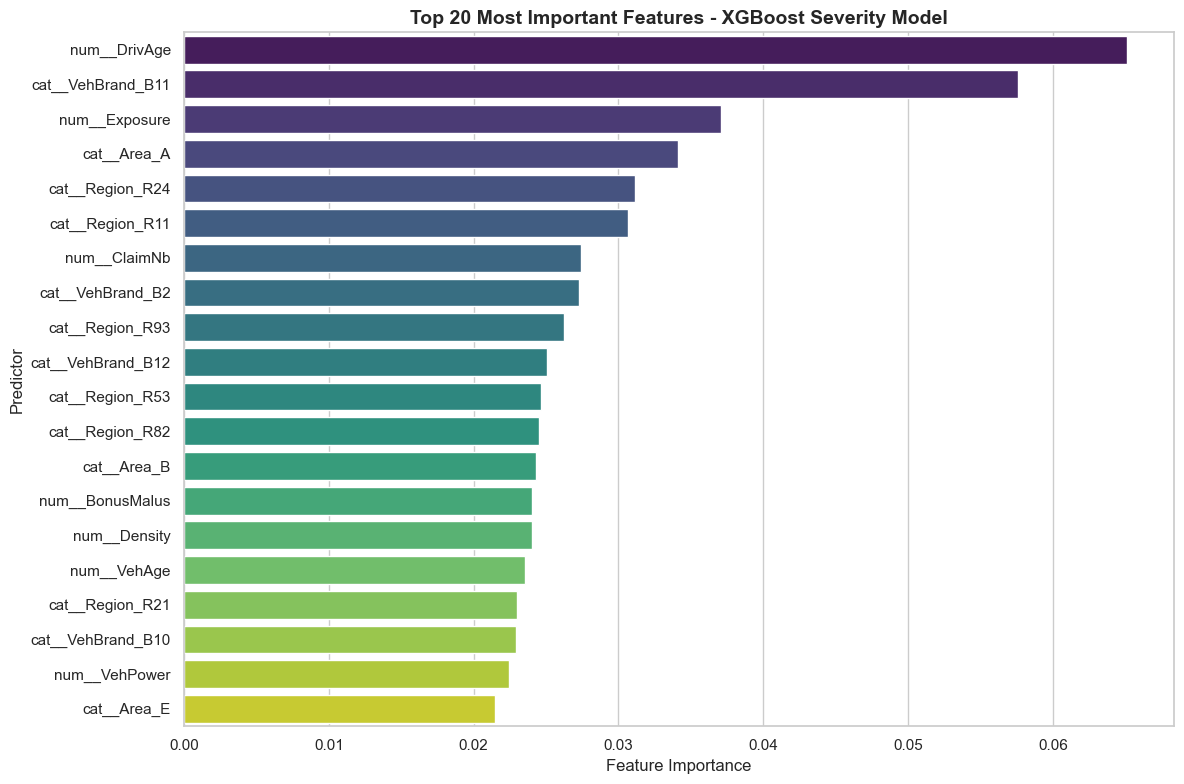

In [27]:
plt.figure(figsize=(12,8))

sns.barplot(
    data=importance_df.head(20),
    y="Feature",
    x="Importance",
    palette="viridis"
)

plt.title(
    "Top 20 Most Important Features - XGBoost Severity Model",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Feature Importance")
plt.ylabel("Predictor")

plt.tight_layout()
plt.show()

# 16. Preparing for Model Explainability

## Motivation

While feature importance identifies globally influential variables, it does not explain how individual predictors influence predictions for specific policyholders.

To address this limitation, SHAP (SHapley Additive exPlanations) will be applied in the next stage of the project.

---

## Why SHAP?

SHAP is based on cooperative game theory and attributes each prediction to individual feature contributions.

Compared with traditional feature importance measures, SHAP provides:

- Local explanations for individual policies.
- Global summaries across the entire portfolio.
- Directional effects showing whether variables increase or decrease predicted severity.

---



# Export XGBoost Severity Predictions

## Objective

The trained XGBoost severity model estimates the expected claim cost conditional on a claim occurring.

To support the modular design of the pricing framework, the model predictions are exported as a standalone dataset. This approach mirrors production machine learning pipelines where independently developed models are consumed by downstream pricing systems.

The exported predictions will be integrated with frequency model outputs in Day 8 to construct multiple Pure Premium pricing engines.

Exporting prediction artifacts rather than relying on in-memory objects improves reproducibility, supports workflow automation, and enables independent validation of each modeling component.

In [28]:
%whos

Variable                  Type                 Data/Info
--------------------------------------------------------
ColumnTransformer         ABCMeta              <class 'sklearn.compose._<...>ormer.ColumnTransformer'>
OneHotEncoder             type                 <class 'sklearn.preproces<...>_encoders.OneHotEncoder'>
Pipeline                  ABCMeta              <class 'sklearn.pipeline.Pipeline'>
SimpleImputer             type                 <class 'sklearn.impute._base.SimpleImputer'>
X                         DataFrame            Shape: (24944, 11)
XGBRegressor              type                 <class 'xgboost.sklearn.XGBRegressor'>
X_test                    DataFrame            Shape: (4989, 11)
X_train                   DataFrame            Shape: (19955, 11)
categorical_features      list                 n=4
categorical_transformer   Pipeline             Pipeline(steps=[('imputer<...>ndle_unknown='ignore'))])
claim_df                  DataFrame            Shape: (26639, 2)
cla

In [29]:
import pandas as pd

xgb_severity_output = pd.DataFrame({
    "Actual_Severity": y_test.values,
    "XGB_Severity": xgb_predictions
})

xgb_severity_output.to_csv(
    "xgb_severity_predictions.csv",
    index=False
)

print("✓ XGBoost severity predictions exported successfully.")

✓ XGBoost severity predictions exported successfully.


In [30]:
xgb_check = pd.read_csv("xgb_severity_predictions.csv")

print(xgb_check.head())
print(xgb_check.shape)

   Actual_Severity  XGB_Severity
0          3204.00     1995.8427
1           395.88     2193.6272
2          1204.00     1291.4049
3          1128.00     1123.4445
4          2528.12     1860.8809
(4989, 2)
